NLP Sentiment Analysis:Extracting sentiment from customer reviews on a product

In [1]:
!pip install emoji
!pip install nltk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('/content/dataset -P667_Modified.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


Check for Empty entries

In [4]:
df.isnull().sum()

,0
title,0
rating,0
body,0


Combine the text columns to single columns

In [5]:
df['Combined'] = df['title'] + " " + df['body']
df = df.drop(columns=['title', 'body'])


Remove non ASCII characters

In [6]:
import re
non_ascii_pattern = r'([^\x20-\x7E])'
# 2. Check a specific column for these characters
# This returns a boolean mask (True/False)

mask = df['Combined'].str.contains(non_ascii_pattern, na=False, regex=True)

# 3. View the rows that contain "unrecognized" characters
bad_data = df[mask]
print(bad_data)

      rating                                           Combined
7          1  “It doesn’t even look 10% as good as they show...
9          1  Don’t buy from Amazon. Very poor quality camer...
23         3  Not So impressive,okay okay.Little over price ...
28         5  It's a budget package. A good phone to buy in ...
30         3  Good battery but average performance Pros:1. T...
...      ...                                                ...
1386       5  Nice One. Batterry and fingerprint sensor is v...
1387       5  Amazing🔥 cost effective, best ever battery lif...
1392       1  No WiFi calling the phone does not support “Wi...
1394       5  Good The media could not be loaded.\n         ...
1426       5  True monster Quality product by samsungVery ni...

[204 rows x 2 columns]


/tmp/ipykernel_27090/50187677.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['Combined'].str.contains(non_ascii_pattern, na=False, regex=True)


Remove Emoji's

In [7]:
import emoji

def replace_emojis(text):
    if isinstance(text, str):
        return emoji.demojize(text)
    return text

df['Combined'] = df['Combined'].apply(replace_emojis)

View the rows that contain "unrecognized" characters

In [8]:
mask = df['Combined'].str.contains(non_ascii_pattern, na=False, regex=True)

# View the rows that contain "unrecognized" characters
bad_data = df[mask]
print(bad_data)

      rating                                           Combined
7          1  “It doesn’t even look 10% as good as they show...
9          1  Don’t buy from Amazon. Very poor quality camer...
23         3  Not So impressive,okay okay.Little over price ...
28         5  It's a budget package. A good phone to buy in ...
30         3  Good battery but average performance Pros:1. T...
...      ...                                                ...
1305       2  Dont buy this The media could not be loaded.\n...
1319       1  Bad product.don't buy it..such a waste of mone...
1369       5  This phone has a very good camera and battery ...
1392       1  No WiFi calling the phone does not support “Wi...
1394       5  Good The media could not be loaded.\n         ...

[103 rows x 2 columns]


/tmp/ipykernel_27090/790359222.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df['Combined'].str.contains(non_ascii_pattern, na=False, regex=True)


Convert to lower case

In [9]:
df['Combined'] = df['Combined'].str.lower()

Remove noise. Noise here means website address, Special characters, punctuation

In [10]:

def remove_noise(text):
    if not isinstance(text, str):
        return text

    # 1. Remove URLs (http/https)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 2. Remove Special Characters and Punctuation
    # This keeps only letters (a-z) and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Remove extra whitespace/newlines
    text = " ".join(text.split())

    return text

# Apply to your lowercase, combined column
df['Combined'] = df['Combined'].apply(remove_noise)
print(df['Combined'])

0       horrible product very disappointed with the ov...
1       camera quality is not like megapixel camera qu...
2       overall got the mobile on the launch datebatte...
3       a big no from me it doesnt work with ghz wifi ...
4       put your money somewhere else not worth buying...
                              ...                        
1435                    excellent mobile excellent mobile
1436    never expected from samsung all over mobile pe...
1437    good value for money battery life is good but ...
1438    unreal and whitish display its a very bad prod...
1439    beast of the best the phone is a real beast th...
Name: Combined, Length: 1440, dtype: object


Word Tokenization:
Word tokenization is the foundational Natural Language Processing (NLP) technique of breaking raw text into smaller, meaningful units called tokens—typically individual words—by removing spaces and punctuation

In [11]:
import nltk
from nltk.tokenize import word_tokenize

# Download the necessary tools
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError

# Apply tokenization
df['Tokens'] = df['Combined'].apply(lambda x: word_tokenize(str(x)))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
print(df['Tokens'].tolist())

[['horrible', 'product', 'very', 'disappointed', 'with', 'the', 'overall', 'performance', 'from', 'samsung'], ['camera', 'quality', 'is', 'not', 'like', 'megapixel', 'camera', 'quality', 'is', 'low'], ['overall', 'got', 'the', 'mobile', 'on', 'the', 'launch', 'datebattery', 'must', 'be', 'appreciatedcamera', 'is', 'just', 'averagemobile', 'performance', 'is', 'above', 'averagehz', 'refresh', 'rate', 'if', 'u', 'r', 'buying', 'the', 'mobile', 'for', 'this', 'feature', 'then', 'im', 'afraid', 'u', 'may', 'get', 'disappointed', 'its', 'just', 'normalthe', 'usb', 'cable', 'is', 'too', 'small', 'in', 'lengthits', 'a', 'good', 'mobile', 'in', 'this', 'budget', 'there', 'are', 'no', 'returns', 'for', 'this', 'only', 'replacement', 'is', 'available', 'hence', 'choose', 'wisely', 'before', 'buying'], ['a', 'big', 'no', 'from', 'me', 'it', 'doesnt', 'work', 'with', 'ghz', 'wifi', 'frequency', 'ghz', 'is', 'very', 'old', 'school', 'camera', 'quality', 'is', 'pathetic', 'both', 'front', 'and', 'ba

In [13]:
from collections import Counter
import itertools

# Flatten the list of lists in the 'Tokens' column
all_tokens = list(itertools.chain.from_iterable(df['Tokens']))

# Count token frequencies
token_frequencies = Counter(all_tokens)

# Display the 10 most common tokens
print("Top 10 most common tokens:")
for token, count in token_frequencies.most_common(10):
    print(f"'{token}': {count}")

Top 10 most common tokens:
'is': 3244
'the': 2304
'phone': 1806
'and': 1757
'this': 1537
'for': 1467
'not': 1443
'good': 1375
'to': 1338
'i': 1308


Stop words removal:Stopword removal is an NLP preprocessing technique that eliminates common, low-information words (e.g., "the," "is," "and") to focus on significant content, reduce data dimensionality, and speed up analysis

In [14]:
from nltk.corpus import stopwords
nltk.download('stopwords')
# 1. Load the set of English stopwords
stop_words = set(stopwords.words('english'))

# 2. Define the removal function
def remove_stopwords(token_list):
    # This keeps only words that are NOT in the stop_words list
    return [word for word in token_list if word not in stop_words]

# 3. Apply to your Tokens column
df['Tokens_Clean'] = df['Tokens'].apply(remove_stopwords)

# 4. View the result
print(df[['Tokens', 'Tokens_Clean']].head())

                                              Tokens  \
0  [horrible, product, very, disappointed, with, ...   
1  [camera, quality, is, not, like, megapixel, ca...   
2  [overall, got, the, mobile, on, the, launch, d...   
3  [a, big, no, from, me, it, doesnt, work, with,...   
4  [put, your, money, somewhere, else, not, worth...   

                                        Tokens_Clean  
0  [horrible, product, disappointed, overall, per...  
1  [camera, quality, like, megapixel, camera, qua...  
2  [overall, got, mobile, launch, datebattery, mu...  
3  [big, doesnt, work, ghz, wifi, frequency, ghz,...  
4  [put, money, somewhere, else, worth, buyingfau...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Flatten the list of lists in the 'Tokens' column
all_tokens = list(itertools.chain.from_iterable(df['Tokens_Clean']))

# Count token frequencies
token_frequencies = Counter(all_tokens)

# Display the 10 most common tokens
print("Top 10 most common tokens:")
for token, count in token_frequencies.most_common(10):
    print(f"'{token}': {count}")

Top 10 most common tokens:
'phone': 1806
'good': 1375
'camera': 973
'battery': 820
'samsung': 751
'quality': 699
'mobile': 589
'price': 440
'product': 413
'buy': 341


Word lemmatization is a Natural Language Processing (NLP) technique that reduces inflected words to their base dictionary form, known as the lemma (e.g., "running" to "run," "better" to "good").

Why not stemming? Stemming (Fast, Often Inaccurate), but Lemmatization (Slower, Accurate).
Stemming: Best for large-scale information retrieval, search engines, and scenarios where speed is more important than accuracy.
Lemmatization: Ideal for chatbots, text analysis, and applications where understanding the meaning of a word in context is critical.

In [16]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

# 1. Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# 2. Define the lemmatization function
def lemmatize_tokens(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

# 3. Apply to your Tokens_Clean column
df['Tokens_Lemmatized'] = df['Tokens_Clean'].apply(lemmatize_tokens)

# 4. View the result
print(df[['Tokens_Clean', 'Tokens_Lemmatized']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                        Tokens_Clean  \
0  [horrible, product, disappointed, overall, per...   
1  [camera, quality, like, megapixel, camera, qua...   
2  [overall, got, mobile, launch, datebattery, mu...   
3  [big, doesnt, work, ghz, wifi, frequency, ghz,...   
4  [put, money, somewhere, else, worth, buyingfau...   

                                   Tokens_Lemmatized  
0  [horrible, product, disappointed, overall, per...  
1  [camera, quality, like, megapixel, camera, qua...  
2  [overall, got, mobile, launch, datebattery, mu...  
3  [big, doesnt, work, ghz, wifi, frequency, ghz,...  
4  [put, money, somewhere, else, worth, buyingfau...  


In [17]:
# Flatten the list of lists in the 'Tokens' column
all_tokens = list(itertools.chain.from_iterable(df['Tokens_Lemmatized']))

# Count token frequencies
token_frequencies = Counter(all_tokens)

# Display the 10 most common tokens
print("Top 10 most common tokens:")
for token, count in token_frequencies.most_common(10):
    print(f"'{token}': {count}")

token_frequencies.total()

Top 10 most common tokens:
'phone': 1939
'good': 1376
'camera': 998
'battery': 821
'samsung': 751
'quality': 703
'mobile': 615
'price': 445
'product': 438
'day': 368


47841

Distribution of Ratings.

Distribution of Ratings:
rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64




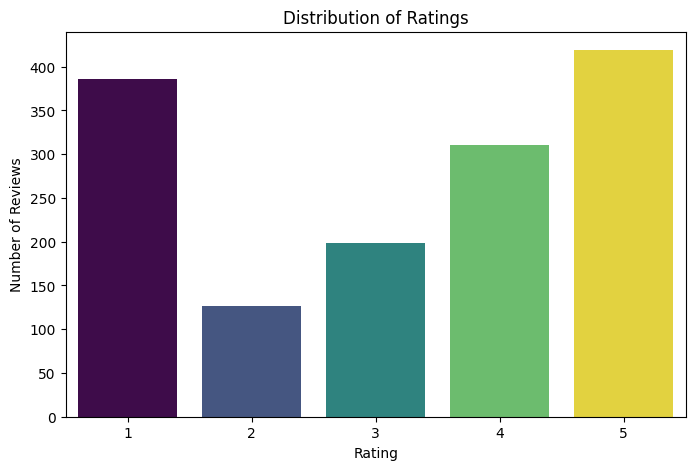

In [18]:

# 1. Distribution of 'rating' column
print("Distribution of Ratings:")
print(df['rating'].value_counts())
print("\n")

# Visualize the distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, hue='rating', palette='viridis', legend=False)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

Most frequent words.

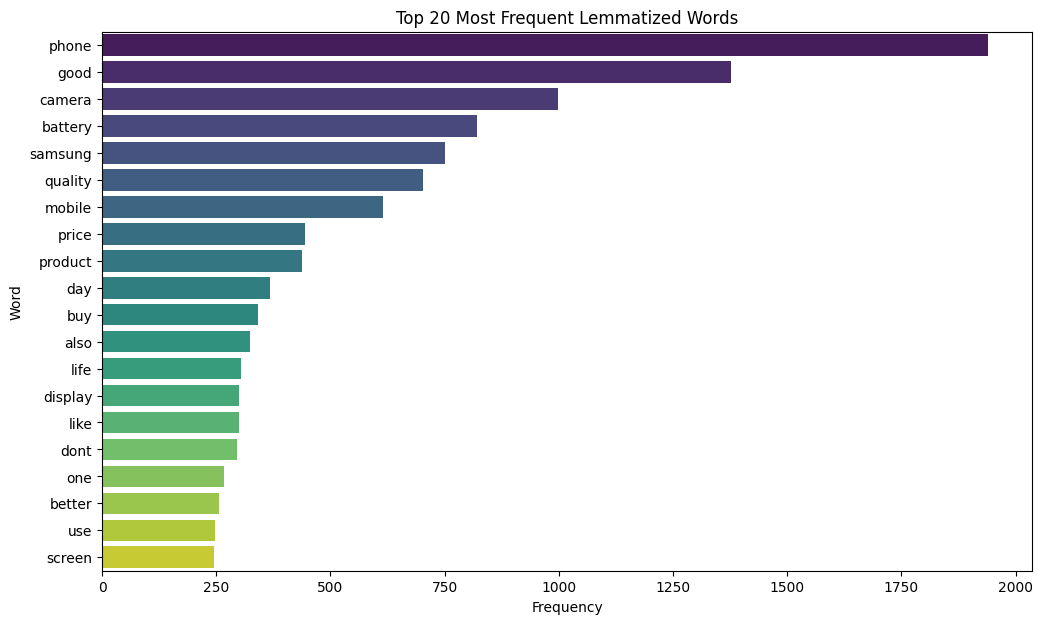

In [19]:


# Get the top N most common words from the lemmatized tokens
top_n_words = 20
most_common_words = token_frequencies.most_common(top_n_words)

# Convert to a DataFrame for easier plotting
words_df = pd.DataFrame(most_common_words, columns=['word', 'frequency'])

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='frequency', y='word', data=words_df, hue='word', palette='viridis', legend=False)
plt.title(f'Top {top_n_words} Most Frequent Lemmatized Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

Review Length

Review Length Distribution:
count    1440.000000
mean       33.222917
std        21.851439
min         2.000000
25%        20.000000
50%        28.000000
75%        40.000000
max       260.000000
Name: review_length, dtype: float64




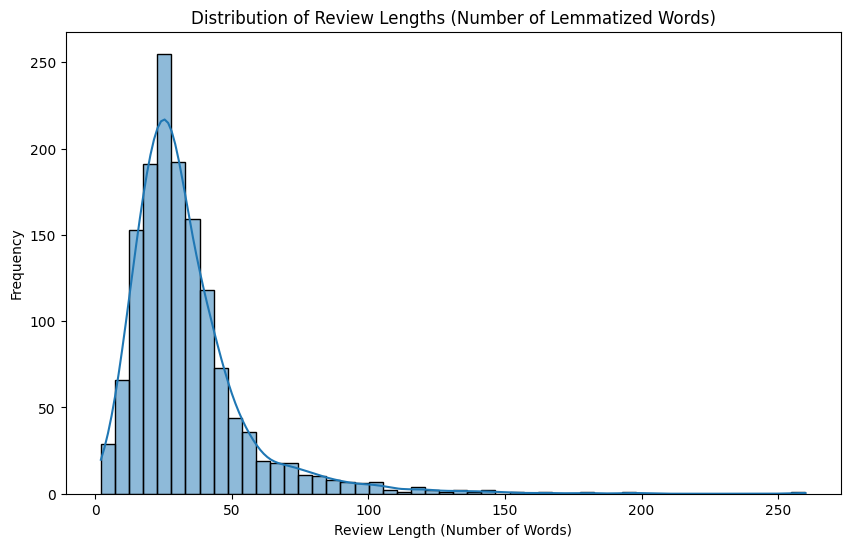

In [20]:

# Calculate the length of each review (number of lemmatized tokens)
df['review_length'] = df['Tokens_Lemmatized'].apply(len)

print("Review Length Distribution:")
print(df['review_length'].describe())
print("\n")

# Plot the distribution of review lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths (Number of Lemmatized Words)')
plt.xlabel('Review Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()

Bigrams: N-grams are contiguous sequences of
items (words, characters, or symbols) extracted from text or speech, widely used in NLP for text analysis, prediction, and classification. They help capture local context, with common types being bigrams (n = 2) and trigrams (n = 3).

In [21]:
from nltk.util import ngrams
from collections import Counter

# 1. Define a function to generate bigrams
def generate_bigrams(token_list):
    # n=2 for bigrams (word pairs)
    return list(ngrams(token_list, 2))

# 2. Apply the function to the 'Tokens_Lemmatized' column
df['Bigrams'] = df['Tokens_Lemmatized'].apply(generate_bigrams)

# 3. Flatten the list of lists of bigrams
all_bigrams = list(itertools.chain.from_iterable(df['Bigrams']))

# 4. Count bigram frequencies
bigram_frequencies = Counter(all_bigrams)

# 5. Display the 15 most common bigrams
print("Top 15 most common bigrams:")
for bigram, count in bigram_frequencies.most_common(15):
    print(f"'{' '.join(bigram)}': {count}")

Top 15 most common bigrams:
'camera quality': 267
'battery life': 241
'good phone': 119
'price range': 116
'budget phone': 103
'dont buy': 98
'good battery': 92
'battery backup': 86
'value money': 85
'quality good': 82
'phone good': 79
'finger print': 72
'gb ram': 66
'samsung phone': 60
'camera good': 58


Create a new column Sentiment

In [22]:
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['rating'].apply(get_sentiment)

In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rating             1440 non-null   int64 
 1   Combined           1440 non-null   object
 2   Tokens             1440 non-null   object
 3   Tokens_Clean       1440 non-null   object
 4   Tokens_Lemmatized  1440 non-null   object
 5   review_length      1440 non-null   int64 
 6   Bigrams            1440 non-null   object
 7   Sentiment          1440 non-null   object
dtypes: int64(2), object(6)
memory usage: 90.1+ KB


Remove unnecessary columns

In [24]:
df = df[['rating', 'Combined', 'Tokens_Lemmatized', 'Sentiment']].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rating             1440 non-null   int64 
 1   Combined           1440 non-null   object
 2   Tokens_Lemmatized  1440 non-null   object
 3   Sentiment          1440 non-null   object
dtypes: int64(1), object(3)
memory usage: 45.1+ KB


Bag of words

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert list of tokens back to string for CountVectorizer
df['Tokens_Lemmatized_Str'] = df['Tokens_Lemmatized'].apply(lambda x: ' '.join(x))

# Initialize CountVectorizer
# You can add parameters like max_features, min_df, max_df if needed
count_vectorizer = CountVectorizer(max_features=5000) # Limiting to 5000 features for demonstration

# Fit and transform the lemmatized text
X_bow = count_vectorizer.fit_transform(df['Tokens_Lemmatized_Str'])

print("Bag of Words (BoW) matrix shape:", X_bow.shape)
print("First 10 feature names (words):")
print(count_vectorizer.get_feature_names_out()[:10])

Bag of Words (BoW) matrix shape: (1440, 5000)
First 10 feature names (words):
['aa' 'able' 'abruptly' 'absentresolution' 'absolute' 'absolutely' 'abt'
 'accept' 'acceptable' 'acceptablebut']


### TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection or corpus. It is often used as a weighting factor in information retrieval and text mining. The TF-IDF value increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus, which helps to adjust for the fact that some words appear more frequently in general.


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# Uses the same `Tokens_Lemmatized_Str` column
tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2)) # Limiting to 5000 features for consistency

# Fit and transform the lemmatized text
X_tfidf = tfidf_vectorizer.fit_transform(df['Tokens_Lemmatized_Str'])

print("TF-IDF matrix shape:", X_tfidf.shape)
print("First 10 feature names (words):")
print(tfidf_vectorizer.get_feature_names_out()[:10])

TF-IDF matrix shape: (1440, 5000)
First 10 feature names (words):
['aa' 'aa href' 'able' 'able connect' 'able hear' 'able return' 'abruptly'
 'absolute' 'absolutely' 'absolutely fine']


Both Bag of words and TF-IDF results same. The output matrix has a shape of (1440, 5000), meaning there are 1440 documents (reviews) and 5000 unique features (words) being considered

In [27]:
y = df['Sentiment']

Train Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
# --- Naive Bayes (MultinomialNB) ---
print("\n--- Training Multinomial Naive Bayes ---")
mnb_model = MultinomialNB()
mnb_model.fit(X_train, y_train)
y_pred_mnb = mnb_model.predict(X_test)

print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("Multinomial Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_mnb))

# --- Logistic Regression ---
print("\n--- Training Logistic Regression ---")
# Increased max_iter for better convergence, and using 'liblinear' solver for multiclass classification
logreg_model = LogisticRegression(max_iter=1000, solver='liblinear')
logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_logreg))

# --- Support Vector Machine (SVM) ---
print("\n--- Training Support Vector Machine (SVC) ---")
# Using a linear kernel for text data which is often high-dimensional
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

# --- Random Forest Classifier ---
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# --- Gradient Boosting Classifier ---
print("\n--- Training Gradient Boosting Classifier ---")
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)
y_pred_gbc = gbc_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gbc))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gbc))



--- Training Multinomial Naive Bayes ---
Multinomial Naive Bayes Accuracy: 0.7534722222222222
Multinomial Naive Bayes Classification Report:
               precision    recall  f1-score   support

    Negative       0.97      0.77      0.85       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.66      0.99      0.79       133

    accuracy                           0.75       288
   macro avg       0.54      0.59      0.55       288
weighted avg       0.68      0.75      0.70       288


--- Training Logistic Regression ---
Logistic Regression Accuracy: 0.7847222222222222
Logistic Regression Classification Report:
               precision    recall  f1-score   support

    Negative       0.93      0.85      0.89       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.71      0.99      0.82       133

    accuracy                           0.78       288
   macro avg       0.55      0.61      0.57       288
weighted avg       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

SVM Accuracy: 0.8055555555555556
SVM Classification Report:
               precision    recall  f1-score   support

    Negative       0.85      0.90      0.87       111
     Neutral       0.67      0.09      0.16        44
    Positive       0.78      0.96      0.86       133

    accuracy                           0.81       288
   macro avg       0.76      0.65      0.63       288
weighted avg       0.79      0.81      0.76       288


--- Training Random Forest Classifier ---
Random Forest Accuracy: 0.7673611111111112
Random Forest Classification Report:
               precision    recall  f1-score   support

    Negative       0.85      0.85      0.85       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.71      0.95      0.82       133

    accuracy                           0.77       288
   macro avg       0.52      0.60      0.56       288
weighted avg       0.66      0.77      0.71       288


--- Training Gradient Boosting Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Gradient Boosting Accuracy: 0.7465277777777778
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.83      0.81       111
     Neutral       0.17      0.02      0.04        44
    Positive       0.73      0.92      0.81       133

    accuracy                           0.75       288
   macro avg       0.57      0.59      0.56       288
weighted avg       0.67      0.75      0.70       288





1.  Gradient Boosting Accuracy: 0.7465277777777778
2.  Random Forest Accuracy: 0.7673611111111112
3.  SVM Accuracy: 0.8055555555555556
4.  Logistic Regression Accuracy: 0.7847222222222222
5.  Multinomial Naive Bayes Accuracy: 0.7534722222222222

SVM accuracy is good compared to others



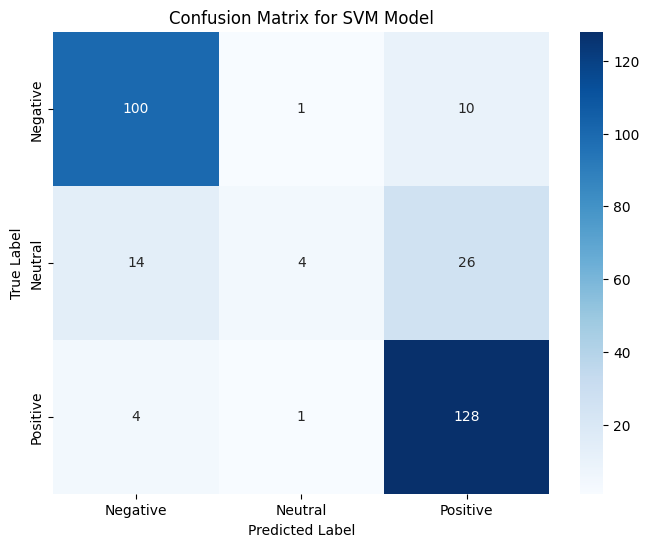

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix for the SVM model
cm = confusion_matrix(y_test, y_pred_svm)

# Get class labels from the SVM model
class_labels = svm_model.classes_ if 'svm_model' in locals() else ['Negative', 'Neutral', 'Positive']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='f1_macro',   # VERY IMPORTANT
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
best_svm = grid.best_estimator_
y_pred_grid = best_svm.predict(X_test)

print(classification_report(y_test, y_pred_grid))
# Ensuring y_pred_grid is defined for subsequent cells.

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87       111
     Neutral       0.50      0.32      0.39        44
    Positive       0.79      0.89      0.84       133

    accuracy                           0.80       288
   macro avg       0.72      0.69      0.70       288
weighted avg       0.78      0.80      0.78       288



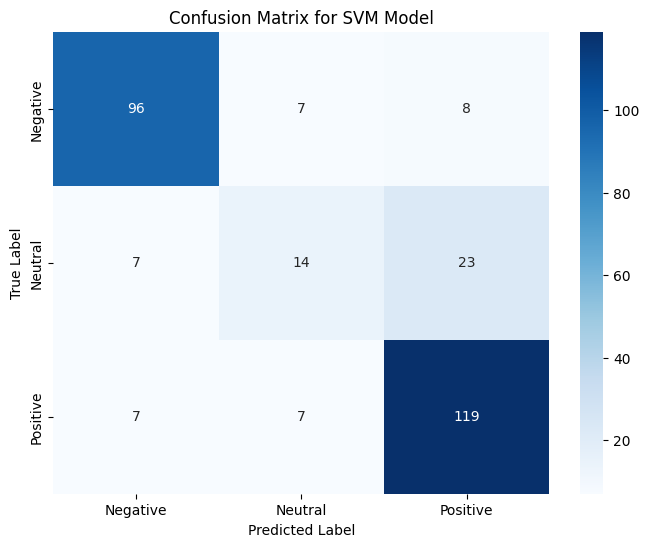

In [32]:
# Get the confusion matrix for the SVM model
cm = confusion_matrix(y_test, y_pred_grid)

# Get class labels from the SVM model
class_labels = svm_model.classes_ if 'svm_model' in locals() else ['Negative', 'Neutral', 'Positive']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Binary Version

In [33]:
df.drop(df[df['Sentiment'] == 'Neutral'].index, inplace=True)

In [34]:
# Initialize TfidfVectorizer
# Uses the same `Tokens_Lemmatized_Str` column
tfidf_vectorizer_1 = TfidfVectorizer(max_features=5000,ngram_range=(1,2)) # Limiting to 5000 features for consistency
# Fit and transform the lemmatized text
X_tfidf_1 = tfidf_vectorizer_1.fit_transform(df['Tokens_Lemmatized_Str'])

print("TF-IDF matrix shape:", X_tfidf_1.shape)
print("First 10 feature names (words):")
print(tfidf_vectorizer_1.get_feature_names_out()[:10])
y = df['Sentiment']
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_tfidf_1, y, test_size=0.2, random_state=42
)
# --- Naive Bayes (MultinomialNB) ---
print("\n--- Training Multinomial Naive Bayes ---")
mnb_model1 = MultinomialNB()
mnb_model1.fit(X_train1, y_train1)
y_pred_mnb1 = mnb_model1.predict(X_test1)

print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test1, y_pred_mnb1))
print("Multinomial Naive Bayes Classification Report:\n", classification_report(y_test1, y_pred_mnb1))

# --- Logistic Regression ---
print("\n--- Training Logistic Regression ---")
# Increased max_iter for better convergence, and using 'liblinear' solver for multiclass classification
logreg_model1 = LogisticRegression(max_iter=1000, solver='liblinear')
logreg_model1.fit(X_train1, y_train1)
y_pred_logreg1 = logreg_model1.predict(X_test1)

print("Logistic Regression Accuracy:", accuracy_score(y_test1, y_pred_logreg1))
print("Logistic Regression Classification Report:\n", classification_report(y_test1, y_pred_logreg1))

# --- Support Vector Machine (SVM) ---
print("\n--- Training Support Vector Machine (SVC) ---")
# Using a linear kernel for text data which is often high-dimensional
svm_model1 = SVC(kernel='linear')
svm_model1.fit(X_train1, y_train1)
y_pred_svm1 = svm_model1.predict(X_test1)

print("SVM Accuracy:", accuracy_score(y_test1, y_pred_svm1))
print("SVM Classification Report:\n", classification_report(y_test1, y_pred_svm1))

# --- Random Forest Classifier ---
print("\n--- Training Random Forest Classifier ---")
rf_model1 = RandomForestClassifier(random_state=42)
rf_model1.fit(X_train1, y_train1)
y_pred_rf1 = rf_model1.predict(X_test1)

print("Random Forest Accuracy:", accuracy_score(y_test1, y_pred_rf1))
print("Random Forest Classification Report:\n", classification_report(y_test1, y_pred_rf1))

# --- Gradient Boosting Classifier ---
print("\n--- Training Gradient Boosting Classifier ---")
gbc_model1 = GradientBoostingClassifier(random_state=42)
gbc_model1.fit(X_train1, y_train1)
y_pred_gbc1 = gbc_model1.predict(X_test1)

print("Gradient Boosting Accuracy:", accuracy_score(y_test1, y_pred_gbc1))
print("Gradient Boosting Classification Report:\n", classification_report(y_test1, y_pred_gbc1))

TF-IDF matrix shape: (1241, 5000)
First 10 feature names (words):
['aa' 'aa href' 'able' 'able connect' 'able find' 'able hear'
 'able return' 'absolute' 'absolutely' 'accept']

--- Training Multinomial Naive Bayes ---
Multinomial Naive Bayes Accuracy: 0.8995983935742972
Multinomial Naive Bayes Classification Report:
               precision    recall  f1-score   support

    Negative       0.94      0.80      0.86        99
    Positive       0.88      0.97      0.92       150

    accuracy                           0.90       249
   macro avg       0.91      0.88      0.89       249
weighted avg       0.90      0.90      0.90       249


--- Training Logistic Regression ---
Logistic Regression Accuracy: 0.9236947791164659
Logistic Regression Classification Report:
               precision    recall  f1-score   support

    Negative       0.93      0.87      0.90        99
    Positive       0.92      0.96      0.94       150

    accuracy                           0.92       249
   m

1.   Gradient Boosting Accuracy: 0.8714859437751004
2.   Random Forest Accuracy: 0.9036144578313253
3.   SVM Accuracy: 0.9236947791164659
4.   Logistic Regression Accuracy: 0.9236947791164659
5.   Multinomial Naive Bayes Accuracy: 0.8995983935742972




SVM and Logistic regression perfomrs well, We proceed with SVM.

In [35]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}
grid1 = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='f1_macro',   # VERY IMPORTANT
    n_jobs=-1
)

grid1.fit(X_train1, y_train1)
print("Best Parameters:", grid1.best_params_)
best_svm1 = grid1.best_estimator_
y_pred_grid1 = best_svm1.predict(X_test1)

print(classification_report(y_test1, y_pred_grid1))

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90        99
    Positive       0.94      0.93      0.93       150

    accuracy                           0.92       249
   macro avg       0.92      0.92      0.92       249
weighted avg       0.92      0.92      0.92       249



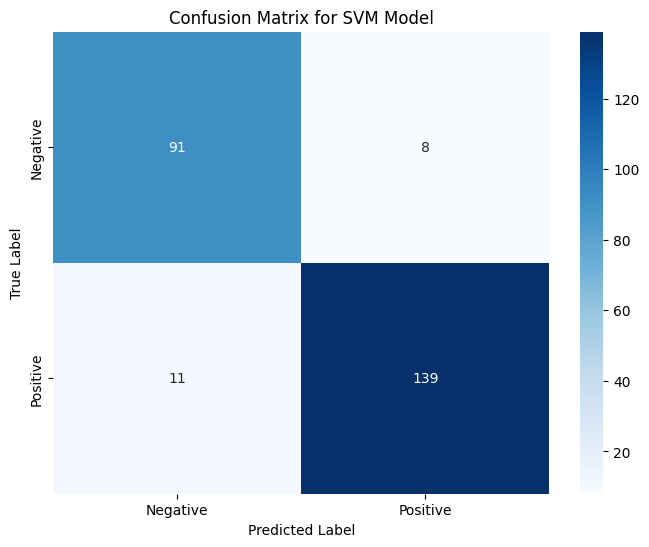

In [36]:
# Get the confusion matrix for the SVM model
cm = confusion_matrix(y_test1, y_pred_svm1)
#cm = confusion_matrix(y_test1, y_pred_grid1)
# Get class labels from the SVM model
class_labels = svm_model1.classes_ if 'svm_model' in locals() else ['Negative', 'Positive']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [38]:
import joblib

# Define filenames for the models and vectorizers
tfidf_vectorizer_filename_3_sentiment = 'tfidf_vectorizer_3_sentiment.joblib'
best_svm_model_filename_3_sentiment = 'svm_model_3_sentiment.joblib'

tfidf_vectorizer_filename_2_sentiment = 'tfidf_vectorizer_2_sentiment.joblib'
svm_model_filename_2_sentiment = 'svm_model_2_sentiment.joblib'

# Save the 3-sentiment models and vectorizers
joblib.dump(tfidf_vectorizer, tfidf_vectorizer_filename_3_sentiment)
joblib.dump(svm_model, best_svm_model_filename_3_sentiment)
print(f"3-sentiment TF-IDF vectorizer saved to {tfidf_vectorizer_filename_3_sentiment}")
print(f"3-sentiment SVM model saved to {best_svm_model_filename_3_sentiment}")

# Save the 2-sentiment models and vectorizers
joblib.dump(tfidf_vectorizer_1, tfidf_vectorizer_filename_2_sentiment)
joblib.dump(svm_model1, svm_model_filename_2_sentiment)
print(f"2-sentiment TF-IDF vectorizer saved to {tfidf_vectorizer_filename_2_sentiment}")
print(f"2-sentiment SVM model saved to {svm_model_filename_2_sentiment}")


3-sentiment TF-IDF vectorizer saved to tfidf_vectorizer_3_sentiment.joblib
3-sentiment SVM model saved to svm_model_3_sentiment.joblib
2-sentiment TF-IDF vectorizer saved to tfidf_vectorizer_2_sentiment.joblib
2-sentiment SVM model saved to svm_model_2_sentiment.joblib
